
#Sprint 2: algoritmos



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [24]:
import sys
import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/HB/proyecto_CDP')
if 'import_ipynb' not in sys.modules:
    !pip install import_ipynb
import import_ipynb
import CDP_0_SRC as cdp0
import CDP_1_SRC as cdp1
from itertools import product
import numpy as np
import random as rn
import time
import networkx as nx
import math

import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import cProfile
import pstats
from scipy import sparse

In [26]:
G = cdp0.crear_grafo()


--- Grafo Creado ---
Número de nodos (autores): 1843
Número de aristas (colaboraciones): 3215


##Algoritmo1 (constructivo): greedy randomized

In [12]:
import random as rn
import numpy as np
from collections import Counter

def algoritmo_constructivo_greedy(grafo, n_comunidades, randomness=0.1):
    """
    Asigna cada nodo a la comunidad más popular entre sus vecinos.
    """
    nodos = list(grafo.nodes())
    num_nodos = len(nodos)

    # En lugar de random, empezamos con "Singleton":
    # Cada autor es su propia comunidad única al principio.
    # Esto permite que las comunidades crezcan orgánicamente.
    solucion = {nodo: i for i, nodo in enumerate(nodos)}

    # 2. Orden aleatorio de visita
    orden_visita = nodos.copy()
    rn.shuffle(orden_visita)

    for nodo_actual in orden_visita:

        # A. Exploración (Aleatorio)
        if rn.random() < randomness:
            # Asignamos una comunidad cualquiera (entre 0 y N)
            solucion[nodo_actual] = rn.randint(0, num_nodos - 1)

        # B. Explotación (Unirse a la mayoría de amigos)
        else:
            solucion = cdp1.generar_vecino_move_majority(solucion, grafo, nodo_actual)

    return solucion

#Algoritmo 2 (Búsqueda Local): Simulated Annealing

###Función de vecindad

In [13]:
def generar_vecino_sa(grafo, particion, nodos, n_comunidades):
    """
    Genera UN vecino modificando la comunidad de un solo nodo aleatorio o un nodo fijo.
    - Si nodo_fijo es None: Elige uno al azar.
    - Si nodo_fijo tiene valor: Procesa ESE nodo específico
    """
    # 1. Hacemos una copia para no modificar la solución original
    vecino = particion.copy()
    nodo = rn.choice(nodos)
    mis_vecinos = list(grafo.neighbors(nodo))

    if mis_vecinos and rn.random() > 0.2: # 80% de veces mover a grupo de un amigo
        vecino_elegido = rn.choice(mis_vecinos)
    else: # 20% de veces mover a cualquier sitio (ruido)
        vecino_elegido = rn.choice(nodos)

    nueva_comunidad = particion.get(vecino_elegido)

    # 5. Aplicamos el cambio (Swap)
    vecino[nodo] = nueva_comunidad

    return vecino


###Algoritmo

In [14]:
import math
def simulated_annealing(grafo, n_comunidades, max_iter=1000, temp_inicial=1.0, alpha=0.99):
    """
    Enfriamiento Simulado.
    max_iter: Número de iteraciones.
    temp_inicial: Temperatura inicial (probabilidad de aceptar cosas malas).
    alpha: Velocidad de enfriamiento.
    """
    lista_nodos = list(grafo.nodes())
    # 1. Solución Inicial (Usamos la aleatoria o la constructiva como semilla)
    solucion_actual = cdp1.generar_particion_random(grafo, n_comunidades) # Empezar random puro
    fitness_actual = cdp1.modularidad(grafo, solucion_actual)

    mejor_solucion = solucion_actual.copy()
    mejor_fitness = fitness_actual

    temp = temp_inicial
    historial = []

    for i in range(max_iter):
        # 2. Generar Vecino
        vecino = generar_vecino_sa(grafo, solucion_actual, lista_nodos, n_comunidades)

        # 3. Evaluar
        fitness_vecino = cdp1.modularidad(grafo, vecino)
        delta = fitness_vecino - fitness_actual

        # 4. Criterio de Aceptación (Metropolis)
        aceptar = False
        if delta > 0:
            aceptar = True
        else:
            probabilidad = math.exp(delta / temp)
            if rn.random() < probabilidad:
                aceptar = True

        if aceptar:
            solucion_actual = vecino
            fitness_actual = fitness_vecino
            if fitness_actual > mejor_fitness:
                mejor_fitness = fitness_actual
                mejor_solucion = solucion_actual.copy()

        # 5. Enfriar
        temp *= alpha
        historial.append(mejor_fitness)

        if i % 100 == 0:
            print(f"SA Iter {i}: Fitness Actual={fitness_actual:.4f} Temp={temp:.4f}")

    return mejor_solucion, historial

##Algoritmo 3 (poblacional): Algoritmo Genético (GA)

### Operadores genéticos

In [15]:
def cruce_uniforme_dict(padre1, padre2, lista_nodos):
    """
    Cruce Uniforme para diccionarios.
    Cada gen (autor) se hereda aleatoriamente del padre1 o del padre2.
    """
    hijo = {}
    for nodo in lista_nodos:
        # 50% de probabilidad de heredar de cada padre
        if rn.random() < 0.5:
            hijo[nodo] = padre1[nodo]
        else:
            hijo[nodo] = padre2[nodo]
    return hijo

def mutacion_dict(individuo, lista_nodos, n_comunidades, prob_mutacion=0.01):
    """
    Recorre todos los nodos y con una probabilidad muy baja cambia su comunidad al azar.
    """
    # Trabajamos sobre el mismo objeto o copia, aquí modificamos in-place si es copia
    for nodo in lista_nodos:
        if rn.random() < prob_mutacion:
            # Mutación: Asignar nueva comunidad aleatoria
            individuo[nodo] = rn.randint(0, n_comunidades - 1)
    return individuo

def torneo_binario(poblacion, fitness_poblacion):
    """
    Selecciona un padre mediante torneo: coge 2 al azar y se queda con el mejor.
    """
    tam = len(poblacion)
    idx1 = rn.randint(0, tam - 1)
    idx2 = rn.randint(0, tam - 1)

    if fitness_poblacion[idx1] > fitness_poblacion[idx2]:
        return poblacion[idx1]
    else:
        return poblacion[idx2]

###Algoritmo

In [16]:

def algoritmo_genetico(grafo, n_comunidades, tam_poblacion=20, generaciones=50, prob_mutacion=0.05):
    """
    Algoritmo Genético Estándar para detección de comunidades.
    """
    lista_nodos = list(grafo.nodes())

    # 1. Inicialización de la Población
    print(f"Generando población inicial ({tam_poblacion} individuos)...")
    poblacion = []
    for _ in range(tam_poblacion):
        # Usamos tu función random
        indiv = cdp1.generar_particion_random(grafo, n_comunidades)
        poblacion.append(indiv)

    # Variables para guardar estadísticas
    mejor_solucion_global = None
    mejor_fitness_global = -1.0
    historial = []

    for gen in range(generaciones):
        # 2. Evaluación
        fitness_vals = []
        for indiv in poblacion:
            # Calculamos fitness (Modularidad)
            f = cdp1.modularidad(grafo, indiv)
            fitness_vals.append(f)

        # 3. Elitismo y Estadísticas
        # Buscamos el mejor de esta generación
        max_fit = max(fitness_vals)
        idx_mejor = fitness_vals.index(max_fit)

        # Actualizamos el mejor histórico
        if max_fit > mejor_fitness_global:
            mejor_fitness_global = max_fit
            mejor_solucion_global = poblacion[idx_mejor].copy()

        historial.append(mejor_fitness_global)

        print(f"Gen {gen}: Mejor Global = {mejor_fitness_global:.4f} (Mejor actual: {max_fit:.4f})")

        # 4. Creación de nueva generación
        nueva_poblacion = []

        # ELITISMO: El mejor pasa directo a la siguiente generación sin cambios
        nueva_poblacion.append(poblacion[idx_mejor].copy())

        # Rellenamos el resto de la población
        while len(nueva_poblacion) < tam_poblacion:
            # A. Selección (Torneo)
            padre1 = torneo_binario(poblacion, fitness_vals)
            padre2 = torneo_binario(poblacion, fitness_vals)

            # B. Cruce
            hijo = cruce_uniforme_dict(padre1, padre2, lista_nodos)

            # C. Mutación
            hijo = mutacion_dict(hijo, lista_nodos, n_comunidades, prob_mutacion)

            nueva_poblacion.append(hijo)

        poblacion = nueva_poblacion

    return mejor_solucion_global, historial

##Experimentación

In [17]:
# Instalar Optuna si no está instalado
!pip install optuna

import optuna
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import numpy as np
from tqdm.notebook import tqdm # Para barra de progreso

# Configuración de estilo para gráficas
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 8.2 MB/s eta 0:00:00


In [29]:
# --- CONFIGURACIÓN DE CALIBRACIÓN ---
# Grafo de entrenamiento (el que ya tienes cargado como G)
GRAFO_CALIBRACION = G
PRESUPUESTO_EVALS_CALIBRACION = 5000  # Menos evals para que la calibración sea rápida
N_COMUNIDADES_TEST = 20 # Probamos con un valor intermedio


def objective_greedy(trial):
    # Calibramos el parámetro 'randomness'
    rand = trial.suggest_float('randomness', 0.0, 0.5)

    # Ejecutamos varias veces y hacemos la media (porque es muy rápido y estocástico)
    scores = []
    for _ in range(5):
        sol = algoritmo_constructivo_greedy(GRAFO_CALIBRACION, n_comunidades=N_COMUNIDADES_TEST, randomness=rand)
        scores.append(cdp1.modularidad(GRAFO_CALIBRACION, sol))

    return np.mean(scores)

def objective_sa(trial):
    """Función objetivo para calibrar Simulated Annealing"""
    # Definir el espacio de búsqueda de hiperparámetros
    temp_inicial = trial.suggest_float('temp_inicial', 0.1, 100.0, log=True)
    alpha = trial.suggest_float('alpha', 0.8, 0.9999)

    # Ejecutar algoritmo
    # Nota: Asegúrate de que simulated_annealing devuelva (mejor_solucion, historial)
    _, historial = simulated_annealing(
        GRAFO_CALIBRACION,
        n_comunidades=N_COMUNIDADES_TEST,
        max_iter=PRESUPUESTO_EVALS_CALIBRACION,
        temp_inicial=temp_inicial,
        alpha=alpha
    )

    # Optuna maximiza el fitness final
    return max(historial)

def objective_ga(trial):
    """Función objetivo para calibrar Algoritmo Genético"""
    tam_poblacion = trial.suggest_int('tam_poblacion', 10, 100)
    prob_mutacion = trial.suggest_float('prob_mutacion', 0.01, 0.5)

    # Calculamos generaciones según el presupuesto: Gen = Evals / Pob
    generaciones = int(PRESUPUESTO_EVALS_CALIBRACION / tam_poblacion)

    _, historial = algoritmo_genetico(
        GRAFO_CALIBRACION,
        n_comunidades=N_COMUNIDADES_TEST,
        tam_poblacion=tam_poblacion,
        generaciones=generaciones,
        prob_mutacion=prob_mutacion
    )

    return max(historial)

# --- EJECUTAR CALIBRACIÓN ---
print("--- Iniciando Calibración Greedy Randomized ---")
study_greedy = optuna.create_study(direction='maximize')
study_greedy.optimize(objective_greedy, n_trials=10) # 10 pruebas
print("Mejores params Greedy:", study_greedy.best_params)

print("--- Iniciando Calibración SA ---")
study_sa = optuna.create_study(direction='maximize')
study_sa.optimize(objective_sa, n_trials=10) # 10 pruebas
print("Mejores params SA:", study_sa.best_params)

print("\n--- Iniciando Calibración GA ---")
study_ga = optuna.create_study(direction='maximize')
study_ga.optimize(objective_ga, n_trials=10) # 10 pruebas
print("Mejores params GA:", study_ga.best_params)

# Guardamos los mejores parámetros
BEST_PARAMS_GREEDY = study_greedy.best_params
BEST_PARAMS_SA = study_sa.best_params
BEST_PARAMS_GA = study_ga.best_params

[I 2026-01-18 16:39:28,688] A new study created in memory with name: no-name-e9581219-59d3-46f4-a97c-190c0d6b410d
[I 2026-01-18 16:39:28,873] Trial 0 finished with value: 0.41345807830726483 and parameters: {'randomness': 0.27470659352434357}. Best is trial 0 with value: 0.41345807830726483.


--- Iniciando Calibración Greedy Randomized ---


[I 2026-01-18 16:39:29,063] Trial 1 finished with value: 0.5114655405473886 and parameters: {'randomness': 0.1705930872537288}. Best is trial 1 with value: 0.5114655405473886.
[I 2026-01-18 16:39:29,277] Trial 2 finished with value: 0.5156942903908834 and parameters: {'randomness': 0.16225962051268833}. Best is trial 2 with value: 0.5156942903908834.
[I 2026-01-18 16:39:29,458] Trial 3 finished with value: 0.4397195195424916 and parameters: {'randomness': 0.2518563581392953}. Best is trial 2 with value: 0.5156942903908834.
[I 2026-01-18 16:39:29,599] Trial 4 finished with value: 0.26562145615513055 and parameters: {'randomness': 0.45835589250128134}. Best is trial 2 with value: 0.5156942903908834.
[I 2026-01-18 16:39:29,750] Trial 5 finished with value: 0.33793405919122016 and parameters: {'randomness': 0.3758787265587137}. Best is trial 2 with value: 0.5156942903908834.
[I 2026-01-18 16:39:30,036] Trial 6 finished with value: 0.6521075099354354 and parameters: {'randomness': 0.0647109

Mejores params Greedy: {'randomness': 0.06471094357179763}
--- Iniciando Calibración SA ---
SA Iter 0: Fitness Actual=-0.0026 Temp=10.7803
SA Iter 100: Fitness Actual=0.0193 Temp=0.0033
SA Iter 200: Fitness Actual=0.0410 Temp=0.0000
SA Iter 300: Fitness Actual=0.0671 Temp=0.0000
SA Iter 400: Fitness Actual=0.0889 Temp=0.0000
SA Iter 500: Fitness Actual=0.1117 Temp=0.0000
SA Iter 600: Fitness Actual=0.1288 Temp=0.0000
SA Iter 700: Fitness Actual=0.1482 Temp=0.0000
SA Iter 800: Fitness Actual=0.1674 Temp=0.0000
SA Iter 900: Fitness Actual=0.1851 Temp=0.0000
SA Iter 1000: Fitness Actual=0.1994 Temp=0.0000
SA Iter 1100: Fitness Actual=0.2097 Temp=0.0000
SA Iter 1200: Fitness Actual=0.2255 Temp=0.0000
SA Iter 1300: Fitness Actual=0.2369 Temp=0.0000
SA Iter 1400: Fitness Actual=0.2586 Temp=0.0000
SA Iter 1500: Fitness Actual=0.2725 Temp=0.0000
SA Iter 1600: Fitness Actual=0.2861 Temp=0.0000
SA Iter 1700: Fitness Actual=0.2978 Temp=0.0000
SA Iter 1800: Fitness Actual=0.3118 Temp=0.0000
SA Ite

[I 2026-01-18 16:40:13,422] Trial 0 finished with value: 0.6143407194047991 and parameters: {'temp_inicial': 11.690148576099524, 'alpha': 0.9221667285947164}. Best is trial 0 with value: 0.6143407194047991.


...

Gen 60: Mejor Global = 0.0153 (Mejor actual: 0.0153)
Generando población inicial (72 individuos)...
Gen 0: Mejor Global = 0.0086 (Mejor actual: 0.0086)
Gen 1: Mejor Global = 0.0086 (Mejor actual: 0.0086)
Gen 2: Mejor Global = 0.0097 (Mejor actual: 0.0097)
Gen 3: Mejor Global = 0.0112 (Mejor actual: 0.0112)
Gen 4: Mejor Global = 0.0112 (Mejor actual: 0.0112)
Gen 5: Mejor Global = 0.0112 (Mejor actual: 0.0112)
Gen 6: Mejor Global = 0.0112 (Mejor actual: 0.0112)
Gen 7: Mejor Global = 0.0112 (Mejor actual: 0.0112)
Gen 8: Mejor Global = 0.0112 (Mejor actual: 0.0112)
Gen 9: Mejor Global = 0.0121 (Mejor actual: 0.0121)
Gen 10: Mejor Global = 0.0121 (Mejor actual: 0.0121)
Gen 11: Mejor Global = 0.0121 (Mejor actual: 0.0121)
Gen 12: Mejor Global = 0.0121 (Mejor actual: 0.0121)
Gen 13: Mejor Global = 0.0122 (Mejor actual: 0.0122)
Gen 14: Mejor Global = 0.0122 (Mejor actual: 0.0122)
Gen 15: Mejor Global = 0.0122 (Mejor actual: 0.0122)
Gen 16: Mejor Global = 0.0122 (Mejor actual: 0.0122)
Gen 17: M

[I 2026-01-18 16:52:30,283] Trial 8 finished with value: 0.013834459354540913 and parameters: {'tam_poblacion': 72, 'prob_mutacion': 0.4823835485369034}. Best is trial 0 with value: 0.03218546675859211.


Gen 68: Mejor Global = 0.0138 (Mejor actual: 0.0138)
Generando población inicial (62 individuos)...
Gen 0: Mejor Global = 0.0073 (Mejor actual: 0.0073)
Gen 1: Mejor Global = 0.0073 (Mejor actual: 0.0073)
Gen 2: Mejor Global = 0.0106 (Mejor actual: 0.0106)
Gen 3: Mejor Global = 0.0106 (Mejor actual: 0.0106)
Gen 4: Mejor Global = 0.0106 (Mejor actual: 0.0106)
Gen 5: Mejor Global = 0.0106 (Mejor actual: 0.0106)
Gen 6: Mejor Global = 0.0106 (Mejor actual: 0.0106)
Gen 7: Mejor Global = 0.0106 (Mejor actual: 0.0106)
Gen 8: Mejor Global = 0.0106 (Mejor actual: 0.0106)
Gen 9: Mejor Global = 0.0106 (Mejor actual: 0.0106)
Gen 10: Mejor Global = 0.0149 (Mejor actual: 0.0149)
Gen 11: Mejor Global = 0.0149 (Mejor actual: 0.0149)
Gen 12: Mejor Global = 0.0149 (Mejor actual: 0.0149)
Gen 13: Mejor Global = 0.0149 (Mejor actual: 0.0149)
Gen 14: Mejor Global = 0.0149 (Mejor actual: 0.0149)
Gen 15: Mejor Global = 0.0149 (Mejor actual: 0.0149)
Gen 16: Mejor Global = 0.0149 (Mejor actual: 0.0149)
Gen 17: M

[I 2026-01-18 16:53:07,611] Trial 9 finished with value: 0.020933754189684805 and parameters: {'tam_poblacion': 62, 'prob_mutacion': 0.1486216185922716}. Best is trial 0 with value: 0.03218546675859211.


Gen 79: Mejor Global = 0.0209 (Mejor actual: 0.0209)
Mejores params GA: {'tam_poblacion': 48, 'prob_mutacion': 0.07688379245991422}


--- Ejecutando Experimento (Max Evals: 10000) ---


Comunidades:   0%|          | 0/6 [00:00<?, ?it/s]

Se han truncado las últimas 5000 líneas del flujo de salida.
Gen 152: Mejor Global = 0.0411 (Mejor actual: 0.0411)
Gen 153: Mejor Global = 0.0411 (Mejor actual: 0.0411)
Gen 154: Mejor Global = 0.0411 (Mejor actual: 0.0411)
Gen 155: Mejor Global = 0.0411 (Mejor actual: 0.0411)
Gen 156: Mejor Global = 0.0411 (Mejor actual: 0.0411)
Gen 157: Mejor Global = 0.0411 (Mejor actual: 0.0411)
Gen 158: Mejor Global = 0.0411 (Mejor actual: 0.0411)
Gen 159: Mejor Global = 0.0411 (Mejor actual: 0.0411)
Gen 160: Mejor Global = 0.0411 (Mejor actual: 0.0411)
Gen 161: Mejor Global = 0.0424 (Mejor actual: 0.0424)
Gen 162: Mejor Global = 0.0424 (Mejor actual: 0.0424)
Gen 163: Mejor Global = 0.0424 (Mejor actual: 0.0424)
Gen 164: Mejor Global = 0.0424 (Mejor actual: 0.0424)
Gen 165: Mejor Global = 0.0424 (Mejor actual: 0.0424)
Gen 166: Mejor Global = 0.0424 (Mejor actual: 0.0424)
Gen 167: Mejor Global = 0.0424 (Mejor actual: 0.0424)
Gen 168: Mejor Global = 0.0424 (Mejor actual: 0.0424)
Gen 169: Mejor Global

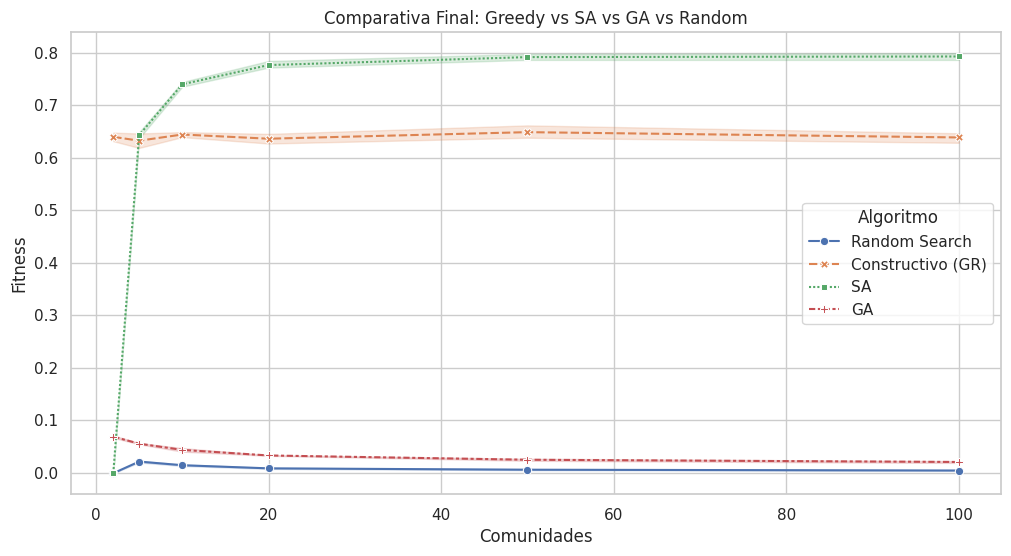

In [30]:
# --- EXPERIMENTO FINAL ---
COMUNIDADES_LISTA = [2, 5, 10, 20, 50, 100]
REPETICIONES = 5
MAX_EVALUACIONES = 10000

resultados = []

print(f"--- Ejecutando Experimento (Max Evals: {MAX_EVALUACIONES}) ---")

for k in tqdm(COMUNIDADES_LISTA, desc="Comunidades"):
    for rep in range(REPETICIONES):

        # 1. Random Search (Baseline)
        start = time.time()
        # Generamos una solución y ya está (Random Search puro es generar muchas y coger la mejor)
        # Simulamos 100 iteraciones de RS para que sea justo
        best_rs = -1
        for _ in range(100):
            s = cdp1.generar_particion_random(G, k)
            f = cdp1.modularidad(G, s)
            if f > best_rs: best_rs = f

        resultados.append({
            'Algoritmo': 'Random Search', 'Comunidades': k, 'Repeticion': rep,
            'Fitness': best_rs, 'Tiempo': time.time() - start
        })

        # 2. Greedy Randomized (Constructivo)
        start = time.time()
        # Usamos el mejor randomness encontrado por Optuna
        sol_cons = algoritmo_constructivo_greedy(G, k, randomness=BEST_PARAMS_GREEDY['randomness'])
        fit_cons = cdp1.modularidad(G, sol_cons)
        resultados.append({
            'Algoritmo': 'Constructivo (GR)', 'Comunidades': k, 'Repeticion': rep,
            'Fitness': fit_cons, 'Tiempo': time.time() - start
        })

        # 3. Simulated Annealing
        start = time.time()
        _, hist_sa = simulated_annealing(
            G, k,
            max_iter=MAX_EVALUACIONES,
            temp_inicial=BEST_PARAMS_SA['temp_inicial'],
            alpha=BEST_PARAMS_SA['alpha']
        )
        resultados.append({
            'Algoritmo': 'SA', 'Comunidades': k, 'Repeticion': rep,
            'Fitness': max(hist_sa), 'Tiempo': time.time() - start
        })

        # 4. Genético
        pop_size = BEST_PARAMS_GA['tam_poblacion']
        gens = max(1, int(MAX_EVALUACIONES / pop_size)) # Evitar 0 generaciones
        start = time.time()
        _, hist_ga = algoritmo_genetico(
            G, k,
            tam_poblacion=pop_size,
            generaciones=gens,
            prob_mutacion=BEST_PARAMS_GA['prob_mutacion']
        )
        resultados.append({
            'Algoritmo': 'GA', 'Comunidades': k, 'Repeticion': rep,
            'Fitness': max(hist_ga), 'Tiempo': time.time() - start
        })

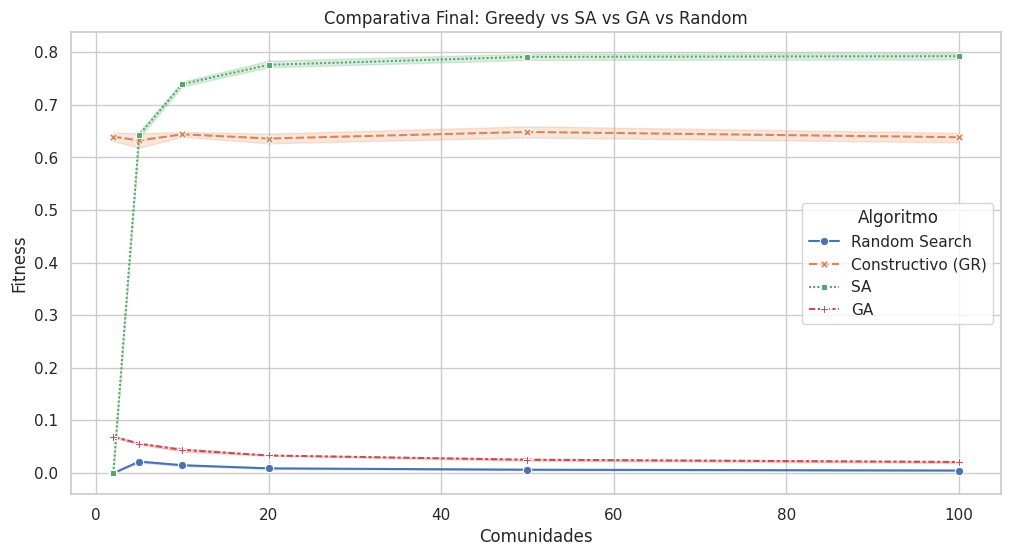

In [31]:
# Generar gráficas finales
df_res = pd.DataFrame(resultados)

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_res, x='Comunidades', y='Fitness', hue='Algoritmo', style='Algoritmo', markers=True)
plt.title('Comparativa Final: Greedy vs SA vs GA vs Random')
plt.show()